Sakshi Jha 00211192024 AIML Group- H Subject: Recent trends in AI

**Experiment 1**

**Aim:** To build a classifier using unlabeled text data based on an encoder-decoder architecture and generate pseudo-labels using clustering.

**Requiremnts:** Tools:
TensorFlow and Keras
NumPy
Pandas
Scikit-learn
Matplotlib

**Theory:** An encoder-decoder architecture is a neural network structure commonly used for processing sequential data such as text. It consists of two main parts: an encoder and a decoder.

The encoder takes the input sequence and converts it into a compact numerical representation called a latent representation. In this experiment, an LSTM (Long Short-Term Memory) network is used as the encoder.

The decoder takes this learned representation and tries to reconstruct the original input sequence. By learning to reconstruct the input, the encoder learns useful representations from the available text data.

Since the given text data is unlabeled, the learned representations can be grouped using K-Means clustering. The resulting cluster numbers are treated as pseudo-labels. These pseudo-labels are then used to train a Logistic Regression classifier.

In [30]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("Libraries imported successfully!")

Libraries imported successfully!


Dataset: IMDB Movie Reviews
Samples: 2000
Text: first 50 words of each review
Original sentiment labels: NOT used
Encoder: LSTM
Latent dimension: 32


In [31]:
from datasets import load_dataset

# Load the IMDB movie review dataset
imdb = load_dataset("stanfordnlp/imdb", split="train")

# Shuffle and select 2000 reviews
imdb_small = imdb.shuffle(seed=42).select(range(2000))

# Use only the review text
# The original sentiment labels are intentionally ignored
texts = [
    " ".join(review.split()[:50])
    for review in imdb_small["text"]
]

print("Dataset: IMDB Movie Reviews")
print("Number of text samples:", len(texts))
print("First review:")
print(texts[0])

Dataset: IMDB Movie Reviews
Number of text samples: 2000
First review:
There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot similarities...


Loads the IMDB Movie Review dataset from Hugging Face.
Shuffles it using seed=42.
Selects 2000 reviews.
Takes the first 50 words from each review to keep the input manageable.
Stores only the review text in texts.


In [32]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

print("Vocabulary size:", len(tokenizer.word_index))
print("First encoded review:")
print(sequences[0])

Vocabulary size: 11587
First encoded review:
[54, 7, 57, 5230, 28, 30, 248, 2559, 4, 2560, 16, 1, 198, 14, 327, 25, 669, 130, 29, 976, 2059, 2560, 297, 5231, 2559, 297, 213, 2560, 1175, 25, 140, 474, 5232, 85, 25, 271, 70, 1334, 2559, 297, 70, 33, 1176, 3394, 47, 98, 23, 6, 1721, 1722]


converts each review from words into numbers.2000 text reviews → Tokenizer → word-to-number conversion → numerical sequences

In [33]:
max_length = max(len(sequence) for sequence in sequences)

X = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post"
)

print("Maximum sequence length:", max_length)
print("Shape of input data:", X.shape)

Maximum sequence length: 63
Shape of input data: (2000, 63)


So we now have 2,000 reviews, each represented using 63 numerical positions.
Shorter reviews were padded with 0s at the end.

In [34]:
embedding_dim = 16
latent_dim = 32
vocab_size = len(tokenizer.word_index) + 1

encoder_inputs = Input(shape=(max_length,))

encoder_embedding = Embedding(
    vocab_size,
    embedding_dim,
    mask_zero=True
)(encoder_inputs)

encoder_lstm = LSTM(
    latent_dim,
    return_state=True
)

encoder_outputs, state_h, state_c = encoder_lstm(
    encoder_embedding
)

encoder_model = Model(
    encoder_inputs,
    [encoder_outputs, state_h, state_c]
)

print("Improved encoder created successfully!")
print("Vocabulary size:", vocab_size)
print("Embedding dimension:", embedding_dim)
print("Latent dimension:", latent_dim)
print("Padding mask: Enabled")

Improved encoder created successfully!
Vocabulary size: 11588
Embedding dimension: 16
Latent dimension: 32
Padding mask: Enabled


In [35]:
decoder_inputs = Input(shape=(max_length - 1,))

decoder_embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    mask_zero=True
)

decoder_embedding = decoder_embedding_layer(decoder_inputs)

decoder_lstm = LSTM(
    latent_dim,
    return_sequences=True,
    return_state=True
)

decoder_outputs, _, _ = decoder_lstm(
    decoder_embedding,
    initial_state=[state_h, state_c]
)

decoder_dense = Dense(
    vocab_size,
    activation="softmax"
)

decoder_outputs = decoder_dense(decoder_outputs)

autoencoder = Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs
)

print("Improved decoder created successfully!")
print("Decoder input shape:", decoder_inputs.shape)
print("Decoder output shape:", decoder_outputs.shape)
print("Padding mask: Enabled")

Improved decoder created successfully!
Decoder input shape: (None, 62)
Decoder output shape: (None, 62, 11588)
Padding mask: Enabled


In [37]:
autoencoder.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Improved autoencoder compiled suc23cessfully!")
print("Optimizer: Adam")
print("Loss: Sparse Categorical Crossentropy") # Compile cell
print("Padding mask: Enabled")

Improved autoencoder compiled successfully!
Optimizer: Adam
Loss: Sparse Categorical Crossentropy
Padding mask: Enabled


Adam → updates the model weights during training.
Sparse Categorical Crossentropy → measures how well the decoder reconstructs the next word.

In [21]:
num_epochs = 50
batch_size = 4

history = autoencoder.fit(
    [X, decoder_input_data],
    decoder_target_data,
    epochs=num_epochs,
    batch_size=batch_size,
    verbose=1
)

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 68s 123ms/step - accuracy: 0.0521 - loss: 7.1600
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 125ms/step - accuracy: 0.0526 - loss: 6.6992
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 123ms/step - accuracy: 0.0534 - loss: 6.6353
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 61s 122ms/step - accuracy: 0.0622 - loss: 6.5640
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 120ms/step - accuracy: 0.0796 - loss: 6.4641
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 59s 117ms/step - accuracy: 0.0862 - loss: 6.3651
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 63s 126ms/step - accuracy: 0.0961 - loss: 6.2777
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 80s 122ms/step - accuracy: 0.1058 - loss: 6.2004
Epoch 9/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 58s 116ms/step - accuracy: 0.1126 - loss: 6.1189
Epoch 10/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 86s 124ms/step - accuracy: 0.1208 - loss: 6.0338
Epoch 11/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 80s 119ms/step - accuracy: 0.1293 - loss: 5.9480
Epoch 12/50
500/500

Loss: 7.1600 → 4.4589 ↓
Accuracy: 5.21% → 22.85% ↑
So the model is learning to reconstruct the reviews.

In [22]:
latent_representations, _, _ = encoder_model.predict(X)

print("Improved latent representation shape:", latent_representations.shape)

print("Minimum value:", latent_representations.min())
print("Maximum value:", latent_representations.max())
print("Mean value:", latent_representations.mean())
print("Standard deviation:", latent_representations.std())

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Improved latent representation shape: (2000, 32)
Minimum value: -0.99996704
Maximum value: 0.9999563
Mean value: 0.2928086
Standard deviation: 0.8003176


In [23]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(latent_representations)

print("Cluster distribution:")
print(np.bincount(cluster_labels))

Cluster distribution:
[1496  504]


PCA representation shape: (2000, 2)
Explained variance ratio: [0.51036197 0.2944286 ]
Total variance explained: 0.80479056


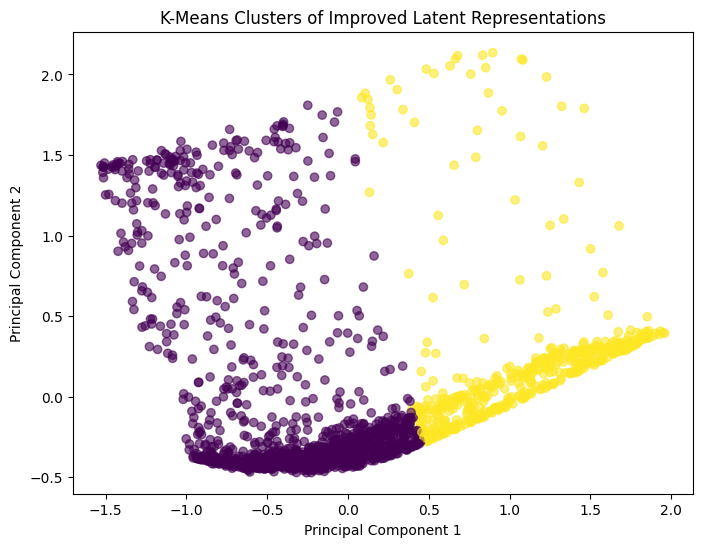

In [24]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

latent_2d = pca.fit_transform(latent_representations)

print("PCA representation shape:", latent_2d.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print(
    "Total variance explained:",
    pca.explained_variance_ratio_.sum()
)

plt.figure(figsize=(8, 6))

plt.scatter(
    latent_2d[:, 0],
    latent_2d[:, 1],
    c=cluster_labels,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters of Improved Latent Representations")
plt.show()

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    latent_representations,
    cluster_labels,
    test_size=0.25,
    random_state=42,
    stratify=cluster_labels
)

classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

classifier.fit(X_train, y_train)

predictions = classifier.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Classifier accuracy:", accuracy)

Training samples: 1500
Testing samples: 500
Classifier accuracy: 0.988


In [26]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_test, predictions))

print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       374
           1       1.00      0.95      0.98       126

    accuracy                           0.99       500
   macro avg       0.99      0.98      0.98       500
weighted avg       0.99      0.99      0.99       500

Confusion Matrix:
[[374   0]
 [  6 120]]


In [28]:
new_review = "I really enjoyed this movie. The story was interesting and the acting was excellent."

new_sequence = tokenizer.texts_to_sequences([new_review])

new_padded = pad_sequences(
    new_sequence,
    maxlen=max_length,
    padding="post"
)

new_latent, _, _ = encoder_model.predict(new_padded)

predicted_group = classifier.predict(new_latent)[0]

print("New review:")
print(new_review)

print("\nPredicted Group:", predicted_group)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
New review:
I really enjoyed this movie. The story was interesting and the acting was excellent.

Predicted Group: 0


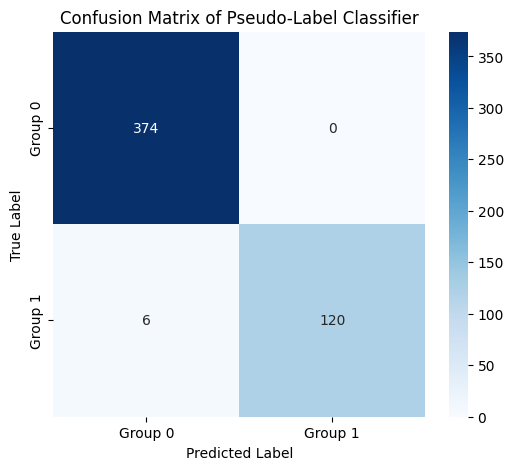

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Group 0", "Group 1"],
    yticklabels=["Group 0", "Group 1"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix of Pseudo-Label Classifier")
plt.show()

Group 0: 1496 reviews
Group 1: 504 reviews
The two groups are visibly separated, especially along Principal Component 1.
There is some overlap, which is normal.

75% = 1500 samples for training
25% = 500 samples for testing
The classifier learns to predict Group 0 / Group 1

This converts the numerical confusion matrix into an easy-to-read graph. 374 Group 0 → correctly predicted
120 Group 1 → correctly predicted
6 Group 1 → predicted as Group 0
0 Group 0 → predicted as Group 1

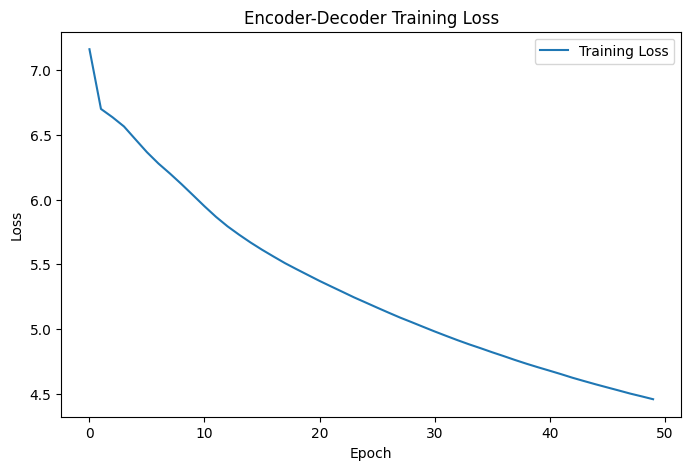

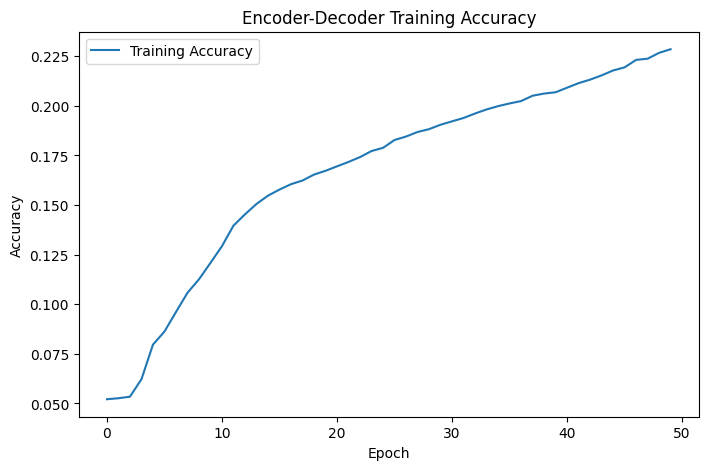

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Encoder-Decoder Training Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Encoder-Decoder Training Accuracy")
plt.legend()
plt.show()

1.Encoder-Decoder Training Loss

Loss steadily decreases from about 7.16 → 4.46.
This shows that the model is learning to reconstruct the input sequences.

2.Encoder-Decoder Training Accuracy

Accuracy steadily increases from about 5.2% → 22.85%.
This confirms that the reconstruction performance improves during training.

**Observation**

The encoder-decoder model using LSTM was successfully built and trained on **2000 text samples from the IMDB movie review dataset**, while the original sentiment labels were intentionally not used. The encoder generated **32-dimensional latent representations** for the text samples.

K-Means clustering was then applied to these latent representations to generate **two pseudo-label groups**, with **1496 samples in Group 0 and 504 samples in Group 1**. These pseudo-labels were used to train a Logistic Regression classifier, which achieved an accuracy of **98.8%** on the test split.

A new text sample was also successfully processed through the encoder and classifier and was assigned to **Group 0**.

The training graphs showed that the reconstruction loss decreased from **7.16 to 4.46**, while reconstruction accuracy increased from **5.21% to 22.85%** over 50 epochs. Since the groups were automatically generated using K-Means and the original sentiment labels were not used, the classifier accuracy represents **pseudo-label classification performance rather than actual sentiment classification performance**.


**Conclusion**

In this practical, an encoder–decoder architecture using LSTM was successfully used to learn representations from 2000 text samples from the IMDB movie review dataset, without using the original sentiment labels. The encoder converted the text sequences into 32-dimensional latent representations, while the decoder learned to reconstruct the input sequences.

K-Means clustering was then applied to the learned representations to generate two pseudo-label groups. A Logistic Regression classifier was trained using these pseudo-labels and achieved 98.8% pseudo-label classification accuracy on the test data. A new text sample was also successfully processed and assigned to Group 0.

Overall, the practical demonstrates how unlabeled text data can be processed using an encoder–decoder architecture to learn meaningful representations and can then be grouped and classified using unsupervised pseudo-labels.
